# 08 – Decision Tree and KNN (M4)
**IT3051 Fundamentals of Data Mining – Mini Project 2026 – PE2 (modelling)**
**Task:** Regression – predict **`Days for shipping (real)`** at order placement.
**Owner:** M4

M4 trains **two models** in this notebook: **Part A – Decision Tree** and **Part B – KNN**. Steps 1–2 run once; Steps 3–7 run once for each model.

### Steps in this notebook
1. Setup (shared helpers – same as notebook 04)
2. Load the data and the team's decisions (M3's features and encoding, M4's scaler and baseline)
3. Choose the model and the settings to try
4. Score the model with default settings
5. Tune the settings with `RandomizedSearchCV`
6. Score the tuned model and compare with the default and the baseline
7. Save the results

### Rules
- Only the **training set** is used. The test set is used **once**, in notebook 09, for the final model.
- Every score uses the **same 5 grouped folds** as the rest of the team, so results are comparable.
- While testing your code, set `N_ITER = 3` to finish fast; set it back for the real run.

**Input:** `data/processed/train_fe.csv`, `results/m3_selection.json`, `results/m4_preprocessing.json`
**Output:** rows in `results/experiments.csv`, `results/params_<model>.json`, a chart in `reports/figures/models/`

## Step 1 – Setup
The team's shared helpers (the same as in notebook 04):
- `regression_metrics` – the 6 scores (**MAE** is the main one: average days wrong).
- `make_cv` – the 5 fair folds: orders stay together, same mix of 0–6 day orders in every fold.
- `cv_evaluate` – trains a fresh model on each fold and returns the average scores and `MAE_std` (how much the score jumps between folds).
- `log_experiment` – adds one result line to the shared `experiments.csv`.
- `build_preprocessor` / `build_full_pipeline` – rebuild M3's encoding, add M4's scaler if needed, then the model – all in one pipeline, so nothing leaks.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import loguniform

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results"
FIG_DIR = ROOT / "reports" / "figures" / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TARGET, GROUP, SEED = "Days for shipping (real)", "Order Id", 42
METRICS = ["MAE", "RMSE", "R2", "MedAE", "within_1_day_%", "bias"]
SCALERS = {"none": None, "standard": StandardScaler, "robust": RobustScaler, "minmax": MinMaxScaler}

def regression_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    err = y_pred - y_true
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "R2": r2_score(y_true, y_pred),
            "MedAE": median_absolute_error(y_true, y_pred),
            "within_1_day_%": float((np.abs(err) <= 1).mean() * 100),
            "bias": float(err.mean())}

def make_cv(X, y, groups, n_splits=5, seed=SEED):
    return list(StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed).split(X, y, groups))

def cv_evaluate(pipe, X, y, cv_splits):
    rows = []
    for i, (tr, va) in enumerate(cv_splits):
        model = clone(pipe).fit(X.iloc[tr], y.iloc[tr])
        rows.append({"fold": i, **regression_metrics(y.iloc[va], model.predict(X.iloc[va]))})
    per_fold = pd.DataFrame(rows)
    summary = {m: float(per_fold[m].mean()) for m in METRICS}
    summary["MAE_std"] = float(per_fold["MAE"].std())
    return summary, per_fold

def log_experiment(row, path=RESULTS_DIR / "experiments.csv"):
    new = pd.DataFrame([row])
    out = pd.concat([pd.read_csv(path), new], ignore_index=True) if path.exists() else new
    out.to_csv(path, index=False)

def build_preprocessor(plan):
    parts = []
    if plan["numeric"]:
        parts.append(("num", SimpleImputer(strategy="median"), plan["numeric"]))
    if plan["onehot"]:
        parts.append(("onehot", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                                          ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), plan["onehot"]))
    if plan["onehot_rare"]:
        parts.append(("onehot_rare", OneHotEncoder(min_frequency=0.01, handle_unknown="infrequent_if_exist",
                                                   sparse_output=False), plan["onehot_rare"]))
    if plan["target"]:
        parts.append(("target", TargetEncoder(target_type="continuous", random_state=SEED), plan["target"]))
    return ColumnTransformer(parts, remainder="drop")

def build_full_pipeline(model, plan, scaler="none"):
    steps = [("prep", build_preprocessor(plan))]
    if SCALERS[scaler] is not None:
        steps.append(("scale", SCALERS[scaler]()))
    steps.append(("model", model))
    return Pipeline(steps)

## Step 2 – Load the data and the team's decisions
Reads M3's features and encoding plan and M4's scaler choice and baseline score, loads the training data and makes the **same 5 folds**
everyone uses. The printed baseline MAE is the number **the model must beat** – otherwise it is no better than
"look up the average for that shipping mode".

In [2]:
m3 = json.loads((RESULTS_DIR / "m3_selection.json").read_text(encoding="utf-8"))
m4 = json.loads((RESULTS_DIR / "m4_preprocessing.json").read_text(encoding="utf-8"))
FEATURES, PLAN, CATEGORY_COL = m3["features"], m3["plan"], m3["category_column"]

train = pd.read_csv(PROCESSED_DIR / "train_fe.csv")
if CATEGORY_COL == "Category Id":
    train[CATEGORY_COL] = train[CATEGORY_COL].astype(str)

X, y, groups = train.drop(columns=[TARGET]), train[TARGET], train[GROUP]
cv_splits = make_cv(X, y, groups)

fam = m4["scaler_by_model_family"]
LINEAR_SCALER = fam["linear (Ridge / Linear Regression)"]["scaler"]
KNN_SCALER = fam["distance (KNN)"]["scaler"]
MODE_BASELINE_MAE = m4["reference_cv_MAE"]["Baseline: mean per Shipping Mode"]

print(f"Train: {len(X):,} rows | features: {FEATURES}")
print(f"Scaler for linear models: {LINEAR_SCALER} | for KNN: {KNN_SCALER}")
print(f"Shipping Mode baseline MAE to beat: {MODE_BASELINE_MAE}")

Train: 138,098 rows | features: ['Shipping Mode', 'Market', 'Order Country', 'Category Name', 'Order Item Quantity', 'Customer Segment', 'order_weekday', 'order_month', 'order_hour', 'order_quarter', 'is_weekend']
Scaler for linear models: minmax | for KNN: minmax
Shipping Mode baseline MAE to beat: 0.9867


# Part A – Decision Tree

## Step 3 – Choose the model (Decision Tree)

**How a Decision Tree works:** it asks yes/no questions ("Is it First Class?", "Is the quantity above 2?") one after another until it
reaches a group of similar orders, then predicts their average days.
**Scaling:** not needed – it splits on thresholds.
**Strengths / weaknesses:** very easy to explain and draw; a single tree overfits easily if it grows too deep.

| Setting | What it controls |
| --- | --- |
| `max_depth` | how many questions in a row (deeper = more complex) |
| `min_samples_leaf` | smallest group at the end of a branch (bigger = smoother) |
| `min_samples_split` | smallest group that may still be split |

In [3]:
from sklearn.tree import DecisionTreeRegressor

MODEL_NAME, OWNER = "DecisionTree", "M4"
MODEL = DecisionTreeRegressor(random_state=SEED)
SCALER = "none"
PARAMS = {
    "model__max_depth": [3, 5, 8, 10, 12, 15, 20, None],
    "model__min_samples_leaf": [1, 5, 10, 20, 50, 100],
    "model__min_samples_split": [2, 10, 50],
}
N_ITER = 30
SEARCH_JOBS = -1         # a single tree is light, so the search can use all CPU cores

## Step 4 – Score the model with default settings (Decision Tree)
Trains the model with its normal settings on each of the 5 folds and scores it. The per-fold table shows whether the score is stable.
This is the **starting point** that tuning should improve on.

In [4]:
default_pipe = build_full_pipeline(MODEL, PLAN, SCALER)
default_scores, default_folds = cv_evaluate(default_pipe, X, y, cv_splits)

print(f"{MODEL_NAME} (default) - CV MAE {default_scores['MAE']:.4f} ± {default_scores['MAE_std']:.4f}")
print(f"Shipping Mode baseline MAE: {MODE_BASELINE_MAE}")
default_folds.round(4)

DecisionTree (default) - CV MAE 1.3108 ± 0.0091
Shipping Mode baseline MAE: 0.9867


,fold,MAE,RMSE,R2,MedAE,within_1_day_%,bias
0,0,1.3159,1.8356,-0.2745,1.0,61.0260,0.0263
1,1,1.2949,1.8138,-0.2346,1.0,61.8420,-0.0263
2,2,1.3173,1.8384,-0.2695,1.0,60.8768,0.0049
3,3,1.3135,1.8358,-0.2854,1.0,61.2597,0.0384
4,4,1.3121,1.8258,-0.2700,1.0,61.1189,-0.0274


## Step 5 – Tune the settings (Decision Tree)
**Tuning** = trying different settings (hyperparameters) and keeping the combination with the lowest error.
`RandomizedSearchCV` tries `N_ITER` random combinations from `PARAMS`, scores each on the **same grouped folds**, and keeps the best.
It is much faster than trying every combination (`GridSearchCV`) and usually finds settings just as good.

How to read the table of the 10 best combinations:
- `val_MAE` – error on data the model did not learn from. **This is the one that matters.**
- `train_MAE` – error on the data it learned from.
- `gap` = val − train. A **big gap means overfitting** (memorising instead of learning). Prefer a low `val_MAE` with a small gap.

Notes: scikit-learn maximises scores, so MAE is used as a negative number and flipped back. KNN is tuned on 30% of the orders
to save time; Step 6 scores the best KNN settings on the **full** data.

In [5]:
X_tune, y_tune, tune_splits = X, y, cv_splits
if MODEL_NAME == "KNN":
    # KNN is very slow on the full data, so tune on 30% of the orders (orders stay whole)
    keep = pd.Series(groups.unique()).sample(frac=0.3, random_state=SEED)
    mask = groups.isin(keep).to_numpy()
    X_tune, y_tune = X[mask].reset_index(drop=True), y[mask].reset_index(drop=True)
    tune_splits = make_cv(X_tune, y_tune, groups[mask].reset_index(drop=True))

search = RandomizedSearchCV(
    build_full_pipeline(MODEL, PLAN, SCALER), PARAMS,
    n_iter=N_ITER, cv=tune_splits, scoring="neg_mean_absolute_error",
    random_state=SEED, n_jobs=SEARCH_JOBS, return_train_score=True,
)
search.fit(X_tune, y_tune)

print("Best settings:", search.best_params_)
print(f"Best CV MAE during tuning: {-search.best_score_:.4f}")

results = pd.DataFrame(search.cv_results_)
results["val_MAE"] = -results["mean_test_score"]
results["train_MAE"] = -results["mean_train_score"]
results["gap"] = results["val_MAE"] - results["train_MAE"]
results.sort_values("val_MAE")[["params", "val_MAE", "train_MAE", "gap"]].head(10).round(4)

Best settings: {'model__min_samples_split': 2, 'model__min_samples_leaf': 50, 'model__max_depth': 3}
Best CV MAE during tuning: 0.9617


,params,val_MAE,train_MAE,gap
27,"{'model__min_samples_split': 10, 'model__min_s...",0.9617,0.9606,0.0010
5,"{'model__min_samples_split': 2, 'model__min_sa...",0.9617,0.9606,0.0010
26,"{'model__min_samples_split': 2, 'model__min_sa...",0.9617,0.9606,0.0010
20,"{'model__min_samples_split': 50, 'model__min_s...",0.9617,0.9606,0.0010
16,"{'model__min_samples_split': 2, 'model__min_sa...",0.9644,0.9613,0.0030
1,"{'model__min_samples_split': 10, 'model__min_s...",0.9644,0.9613,0.0031
9,"{'model__min_samples_split': 2, 'model__min_sa...",0.9644,0.9613,0.0031
28,"{'model__min_samples_split': 50, 'model__min_s...",0.9644,0.9613,0.0031
10,"{'model__min_samples_split': 2, 'model__min_sa...",0.9692,0.9626,0.0065
25,"{'model__min_samples_split': 2, 'model__min_sa...",0.9692,0.9620,0.0073


## Step 6 – Score the tuned model and compare (Decision Tree)
### 6.1 All six scores: baseline vs default vs tuned

In [6]:
tuned_pipe = build_full_pipeline(MODEL, PLAN, SCALER).set_params(**search.best_params_)
tuned_scores, tuned_folds = cv_evaluate(tuned_pipe, X, y, cv_splits)

compare = pd.DataFrame({
    "Shipping Mode baseline": {"MAE": MODE_BASELINE_MAE},
    f"{MODEL_NAME} default": default_scores,
    f"{MODEL_NAME} tuned": tuned_scores,
}).T[["MAE", "MAE_std", "RMSE", "R2", "MedAE", "within_1_day_%", "bias"]]
compare.round(4)

,MAE,MAE_std,RMSE,R2,MedAE,within_1_day_%,bias
Shipping Mode baseline,0.9867,NaN,NaN,NaN,NaN,NaN,NaN
DecisionTree default,1.3108,0.0091,1.8299,-0.2668,1.0000,61.2247,0.0032
DecisionTree tuned,0.9617,0.0103,1.2666,0.3930,0.9897,52.1970,-0.0000


### 6.2 Chart and the two viva answers (Decision Tree)
**Did tuning help?** If MAE improved by more than `MAE_std`, the improvement is real; if less, it is within normal noise.
**Does the model beat the baseline?** If it only just beats it, Shipping Mode carries most of the signal – report that honestly.

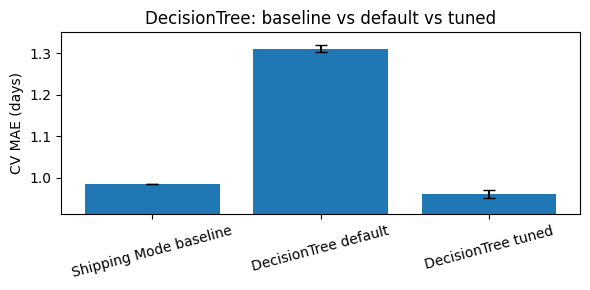

Tuning changed MAE by -0.3491 days (fold noise ± 0.0103)
Improvement is real (bigger than the noise): True
Beats the Shipping Mode baseline: True


In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(compare.index, compare["MAE"], yerr=compare["MAE_std"].fillna(0), capsize=4)
ax.set_ylabel("CV MAE (days)")
ax.set_title(f"{MODEL_NAME}: baseline vs default vs tuned")
ax.set_ylim(compare["MAE"].min() * 0.95, compare["MAE"].max() * 1.03)
plt.xticks(rotation=15)
plt.tight_layout()
fig.savefig(FIG_DIR / f"{MODEL_NAME}_comparison.png", dpi=120)
plt.show()

change = tuned_scores["MAE"] - default_scores["MAE"]
print(f"Tuning changed MAE by {change:+.4f} days (fold noise ± {tuned_scores['MAE_std']:.4f})")
print("Improvement is real (bigger than the noise):", -change > tuned_scores["MAE_std"])
print("Beats the Shipping Mode baseline:", tuned_scores["MAE"] < MODE_BASELINE_MAE)

## Step 7 – Save the results (Decision Tree)
Adds the default and tuned results to the shared `experiments.csv` and saves `results/params_<model>.json` with the best settings.
Notebook 09 reads these files to rebuild each tuned model and pick the winner – the model itself is not saved here.

In [8]:
for label, s in [("default", default_scores), ("tuned", tuned_scores)]:
    log_experiment({"owner": OWNER, "experiment": f"{MODEL_NAME}_{label}", "model": MODEL_NAME,
                    "n_features": len(FEATURES), **{m: s[m] for m in METRICS}, "MAE_std": s["MAE_std"]})

best_params = {k.replace("model__", ""): (v.item() if hasattr(v, "item") else v)
               for k, v in search.best_params_.items()}
summary = {"model": MODEL_NAME, "owner": OWNER, "scaler": SCALER, "best_params": best_params,
           "cv_MAE_default": round(default_scores["MAE"], 4),
           "cv_MAE_tuned": round(tuned_scores["MAE"], 4),
           "cv_MAE_std": round(tuned_scores["MAE_std"], 4),
           "cv_scores_tuned": {m: round(tuned_scores[m], 4) for m in METRICS}}
(RESULTS_DIR / f"params_{MODEL_NAME}.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(json.dumps(summary, indent=2))

{
  "model": "DecisionTree",
  "owner": "M4",
  "scaler": "none",
  "best_params": {
    "min_samples_split": 2,
    "min_samples_leaf": 50,
    "max_depth": 3
  },
  "cv_MAE_default": 1.3108,
  "cv_MAE_tuned": 0.9617,
  "cv_MAE_std": 0.0103,
  "cv_scores_tuned": {
    "MAE": 0.9617,
    "RMSE": 1.2666,
    "R2": 0.393,
    "MedAE": 0.9897,
    "within_1_day_%": 52.197,
    "bias": -0.0
  }
}


### Summary (Decision Tree)

In [9]:
print(f"""
MODEL            {MODEL_NAME} ({OWNER})
SCALER           {SCALER}
DEFAULT CV MAE   {default_scores['MAE']:.4f} ± {default_scores['MAE_std']:.4f}
TUNED CV MAE     {tuned_scores['MAE']:.4f} ± {tuned_scores['MAE_std']:.4f}
BASELINE MAE     {MODE_BASELINE_MAE} (Shipping Mode)  -> beaten: {tuned_scores['MAE'] < MODE_BASELINE_MAE}
BEST SETTINGS    {best_params}
WITHIN 1 DAY     {tuned_scores['within_1_day_%']:.1f}% of orders | R2 {tuned_scores['R2']:.3f} | bias {tuned_scores['bias']:+.3f}
""")


MODEL            DecisionTree (M4)
SCALER           none
DEFAULT CV MAE   1.3108 ± 0.0091
TUNED CV MAE     0.9617 ± 0.0103
BASELINE MAE     0.9867 (Shipping Mode)  -> beaten: True
BEST SETTINGS    {'min_samples_split': 2, 'min_samples_leaf': 50, 'max_depth': 3}
WITHIN 1 DAY     52.2% of orders | R2 0.393 | bias -0.000



# Part B – KNN (k-nearest neighbours)

## Step 3 – Choose the model (KNN)

**How KNN works:** for a new order it finds the **k most similar past orders** (the nearest neighbours) and averages their shipping days.
There is no real "training" – it remembers the training data and compares at prediction time.
**Scaling:** needed – distances depend directly on each column's range (M4 chose the scaler).
**Strengths / weaknesses:** simple idea; slow on large data and weaker when many features are only slightly useful.

| Setting | What it controls |
| --- | --- |
| `n_neighbors` (k) | how many similar orders to average (small = noisy, large = smooth) |
| `weights` | `uniform` = all neighbours equal; `distance` = closer neighbours count more |
| `p` | distance type: 1 = Manhattan, 2 = normal straight-line (Euclidean) |

Because KNN is slow, tuning uses 30% of the orders; the final score in Step 6 uses the full data.

In [10]:
from sklearn.neighbors import KNeighborsRegressor

MODEL_NAME, OWNER = "KNN", "M4"
MODEL = KNeighborsRegressor(n_neighbors=15, n_jobs=-1)
SCALER = KNN_SCALER
PARAMS = {
    "model__n_neighbors": [5, 10, 15, 25, 50, 100],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],
}
N_ITER = 15
SEARCH_JOBS = 1          # KNN already uses all CPU cores

## Step 4 – Score the model with default settings (KNN)
Trains the model with its normal settings on each of the 5 folds and scores it. The per-fold table shows whether the score is stable.
This is the **starting point** that tuning should improve on.

In [11]:
default_pipe = build_full_pipeline(MODEL, PLAN, SCALER)
default_scores, default_folds = cv_evaluate(default_pipe, X, y, cv_splits)

print(f"{MODEL_NAME} (default) - CV MAE {default_scores['MAE']:.4f} ± {default_scores['MAE_std']:.4f}")
print(f"Shipping Mode baseline MAE: {MODE_BASELINE_MAE}")
default_folds.round(4)

KNN (default) - CV MAE 1.0383 ± 0.0095
Shipping Mode baseline MAE: 0.9867


,fold,MAE,RMSE,R2,MedAE,within_1_day_%,bias
0,0,1.0344,1.3500,0.3106,0.9333,53.0728,0.0067
1,1,1.0385,1.3509,0.3151,0.9333,52.6684,-0.0084
2,2,1.0269,1.3365,0.3290,0.9333,52.8464,-0.0221
3,3,1.0530,1.3661,0.2882,1.0000,52.2207,0.0260
4,4,1.0387,1.3519,0.3037,0.9333,52.9393,0.0026


## Step 5 – Tune the settings (KNN)
**Tuning** = trying different settings (hyperparameters) and keeping the combination with the lowest error.
`RandomizedSearchCV` tries `N_ITER` random combinations from `PARAMS`, scores each on the **same grouped folds**, and keeps the best.
It is much faster than trying every combination (`GridSearchCV`) and usually finds settings just as good.

How to read the table of the 10 best combinations:
- `val_MAE` – error on data the model did not learn from. **This is the one that matters.**
- `train_MAE` – error on the data it learned from.
- `gap` = val − train. A **big gap means overfitting** (memorising instead of learning). Prefer a low `val_MAE` with a small gap.

Notes: scikit-learn maximises scores, so MAE is used as a negative number and flipped back. KNN is tuned on 30% of the orders
to save time; Step 6 scores the best KNN settings on the **full** data.

In [12]:
X_tune, y_tune, tune_splits = X, y, cv_splits
if MODEL_NAME == "KNN":
    # KNN is very slow on the full data, so tune on 30% of the orders (orders stay whole)
    keep = pd.Series(groups.unique()).sample(frac=0.3, random_state=SEED)
    mask = groups.isin(keep).to_numpy()
    X_tune, y_tune = X[mask].reset_index(drop=True), y[mask].reset_index(drop=True)
    tune_splits = make_cv(X_tune, y_tune, groups[mask].reset_index(drop=True))

search = RandomizedSearchCV(
    build_full_pipeline(MODEL, PLAN, SCALER), PARAMS,
    n_iter=N_ITER, cv=tune_splits, scoring="neg_mean_absolute_error",
    random_state=SEED, n_jobs=SEARCH_JOBS, return_train_score=True,
)
search.fit(X_tune, y_tune)

print("Best settings:", search.best_params_)
print(f"Best CV MAE during tuning: {-search.best_score_:.4f}")

results = pd.DataFrame(search.cv_results_)
results["val_MAE"] = -results["mean_test_score"]
results["train_MAE"] = -results["mean_train_score"]
results["gap"] = results["val_MAE"] - results["train_MAE"]
results.sort_values("val_MAE")[["params", "val_MAE", "train_MAE", "gap"]].head(10).round(4)

Best settings: {'model__weights': 'uniform', 'model__p': 2, 'model__n_neighbors': 50}
Best CV MAE during tuning: 1.0283


,params,val_MAE,train_MAE,gap
3,"{'model__weights': 'uniform', 'model__p': 2, '...",1.0283,0.9738,0.0545
1,"{'model__weights': 'uniform', 'model__p': 1, '...",1.0334,0.9702,0.0632
8,"{'model__weights': 'distance', 'model__p': 1, ...",1.0355,0.5996,0.4360
11,"{'model__weights': 'uniform', 'model__p': 1, '...",1.0397,0.9300,0.1097
12,"{'model__weights': 'distance', 'model__p': 2, ...",1.0459,0.4656,0.5803
0,"{'model__weights': 'uniform', 'model__p': 1, '...",1.0499,0.8832,0.1667
6,"{'model__weights': 'distance', 'model__p': 1, ...",1.0502,0.4274,0.6227
4,"{'model__weights': 'distance', 'model__p': 2, ...",1.0598,0.3991,0.6607
14,"{'model__weights': 'uniform', 'model__p': 1, '...",1.0645,0.8321,0.2324
5,"{'model__weights': 'distance', 'model__p': 1, ...",1.0652,0.3661,0.6991


## Step 6 – Score the tuned model and compare (KNN)
### 6.1 All six scores: baseline vs default vs tuned

In [13]:
tuned_pipe = build_full_pipeline(MODEL, PLAN, SCALER).set_params(**search.best_params_)
tuned_scores, tuned_folds = cv_evaluate(tuned_pipe, X, y, cv_splits)

compare = pd.DataFrame({
    "Shipping Mode baseline": {"MAE": MODE_BASELINE_MAE},
    f"{MODEL_NAME} default": default_scores,
    f"{MODEL_NAME} tuned": tuned_scores,
}).T[["MAE", "MAE_std", "RMSE", "R2", "MedAE", "within_1_day_%", "bias"]]
compare.round(4)

,MAE,MAE_std,RMSE,R2,MedAE,within_1_day_%,bias
Shipping Mode baseline,0.9867,NaN,NaN,NaN,NaN,NaN,NaN
KNN default,1.0383,0.0095,1.3511,0.3093,0.9467,52.7495,0.0009
KNN tuned,1.0091,0.0094,1.2962,0.3644,0.9640,52.2061,0.0005


### 6.2 Chart and the two viva answers (KNN)
**Did tuning help?** If MAE improved by more than `MAE_std`, the improvement is real; if less, it is within normal noise.
**Does the model beat the baseline?** If it only just beats it, Shipping Mode carries most of the signal – report that honestly.

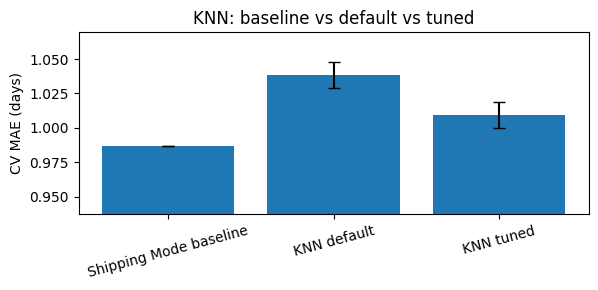

Tuning changed MAE by -0.0292 days (fold noise ± 0.0094)
Improvement is real (bigger than the noise): True
Beats the Shipping Mode baseline: False


In [14]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(compare.index, compare["MAE"], yerr=compare["MAE_std"].fillna(0), capsize=4)
ax.set_ylabel("CV MAE (days)")
ax.set_title(f"{MODEL_NAME}: baseline vs default vs tuned")
ax.set_ylim(compare["MAE"].min() * 0.95, compare["MAE"].max() * 1.03)
plt.xticks(rotation=15)
plt.tight_layout()
fig.savefig(FIG_DIR / f"{MODEL_NAME}_comparison.png", dpi=120)
plt.show()

change = tuned_scores["MAE"] - default_scores["MAE"]
print(f"Tuning changed MAE by {change:+.4f} days (fold noise ± {tuned_scores['MAE_std']:.4f})")
print("Improvement is real (bigger than the noise):", -change > tuned_scores["MAE_std"])
print("Beats the Shipping Mode baseline:", tuned_scores["MAE"] < MODE_BASELINE_MAE)

## Step 7 – Save the results (KNN)
Adds the default and tuned results to the shared `experiments.csv` and saves `results/params_<model>.json` with the best settings.
Notebook 09 reads these files to rebuild each tuned model and pick the winner – the model itself is not saved here.

In [15]:
for label, s in [("default", default_scores), ("tuned", tuned_scores)]:
    log_experiment({"owner": OWNER, "experiment": f"{MODEL_NAME}_{label}", "model": MODEL_NAME,
                    "n_features": len(FEATURES), **{m: s[m] for m in METRICS}, "MAE_std": s["MAE_std"]})

best_params = {k.replace("model__", ""): (v.item() if hasattr(v, "item") else v)
               for k, v in search.best_params_.items()}
summary = {"model": MODEL_NAME, "owner": OWNER, "scaler": SCALER, "best_params": best_params,
           "cv_MAE_default": round(default_scores["MAE"], 4),
           "cv_MAE_tuned": round(tuned_scores["MAE"], 4),
           "cv_MAE_std": round(tuned_scores["MAE_std"], 4),
           "cv_scores_tuned": {m: round(tuned_scores[m], 4) for m in METRICS}}
(RESULTS_DIR / f"params_{MODEL_NAME}.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(json.dumps(summary, indent=2))

{
  "model": "KNN",
  "owner": "M4",
  "scaler": "minmax",
  "best_params": {
    "weights": "uniform",
    "p": 2,
    "n_neighbors": 50
  },
  "cv_MAE_default": 1.0383,
  "cv_MAE_tuned": 1.0091,
  "cv_MAE_std": 0.0094,
  "cv_scores_tuned": {
    "MAE": 1.0091,
    "RMSE": 1.2962,
    "R2": 0.3644,
    "MedAE": 0.964,
    "within_1_day_%": 52.2061,
    "bias": 0.0005
  }
}


### Summary (KNN)

In [16]:
print(f"""
MODEL            {MODEL_NAME} ({OWNER})
SCALER           {SCALER}
DEFAULT CV MAE   {default_scores['MAE']:.4f} ± {default_scores['MAE_std']:.4f}
TUNED CV MAE     {tuned_scores['MAE']:.4f} ± {tuned_scores['MAE_std']:.4f}
BASELINE MAE     {MODE_BASELINE_MAE} (Shipping Mode)  -> beaten: {tuned_scores['MAE'] < MODE_BASELINE_MAE}
BEST SETTINGS    {best_params}
WITHIN 1 DAY     {tuned_scores['within_1_day_%']:.1f}% of orders | R2 {tuned_scores['R2']:.3f} | bias {tuned_scores['bias']:+.3f}
""")


MODEL            KNN (M4)
SCALER           minmax
DEFAULT CV MAE   1.0383 ± 0.0095
TUNED CV MAE     1.0091 ± 0.0094
BASELINE MAE     0.9867 (Shipping Mode)  -> beaten: False
BEST SETTINGS    {'weights': 'uniform', 'p': 2, 'n_neighbors': 50}
WITHIN 1 DAY     52.2% of orders | R2 0.364 | bias +0.000



**My contribution in one sentence:** I trained and tuned the Decision Tree and KNN models with the team's grouped cross-validation
and compared each with its default settings and the Shipping Mode baseline.